# 🎬 IMDB Sentiment Analysis Project  
## Week 1 — Exploratory Data Analysis (EDA)

---

## 🌍 Introduction

Artificial Intelligence is becoming more important in understanding human language and emotions. Every day, people leave reviews on platforms such as IMDB, YouTube, Amazon, Reddit, and social media.

These reviews contain opinions, emotions, criticism, and personal experience. However, computers cannot directly understand whether a text is positive or negative. That is why sentiment analysis is an important task in Natural Language Processing.

For this project, I selected the **IMDB Dataset of 50K Movie Reviews** from Kaggle.

The main goal of this project is to build a model that can classify movie reviews as:

- positive
- negative


## 🎯 Week 1 Objectives

The main objectives of Week 1 are:

- understand the dataset structure;
- load and inspect the data;
- check missing values;
- analyze sentiment distribution;
- explore examples of positive and negative reviews;
- analyze review length;
- prepare the dataset for future preprocessing and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 📦 Uploading and Extracting ZIP Dataset

My dataset is stored as a ZIP file.  
In this step, I upload the ZIP file to Google Colab and extract it.

In [9]:
from google.colab import files

uploaded = files.upload()

Saving data final project deep learning.zip to data final project deep learning (1).zip


In [10]:
import zipfile
import os

zip_path = "data final project deep learning.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("data")

print(os.listdir("data"))

['IMDB Dataset.csv']


## 📂 Finding the CSV File

After extracting the ZIP file, I need to find the CSV file that contains the IMDB reviews.

In [13]:
csv_files = []

for root, dirs, files in os.walk("data"):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

csv_files

['data/IMDB Dataset.csv']

In [14]:
dataset_path = csv_files[0]

print("Dataset path:", dataset_path)

Dataset path: data/IMDB Dataset.csv


## 📖 Loading the Dataset

Now I load the CSV file using pandas.

In [15]:
df = pd.read_csv(dataset_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 🔍 First Look at the Dataset

The dataset contains movie reviews written by real IMDB users.  
Each review has a sentiment label.

In [16]:
df.shape

(50000, 2)

The dataset should contain around **50,000 rows** and **2 columns**.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


## 🧾 Dataset Columns

The main columns are:

| Column | Description |
|---|---|
| review | Text of the movie review |
| sentiment | Sentiment label: positive or negative |

In [18]:
df.columns

Index(['review', 'sentiment'], dtype='object')

## ❌ Checking Missing Values

Missing values can create problems during preprocessing and model training.  
So I check whether the dataset contains empty values.

In [19]:
df.isnull().sum()

,0
review,0
sentiment,0


## 😊😡 Sentiment Distribution

Now I check how many positive and negative reviews are in the dataset.

In [20]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


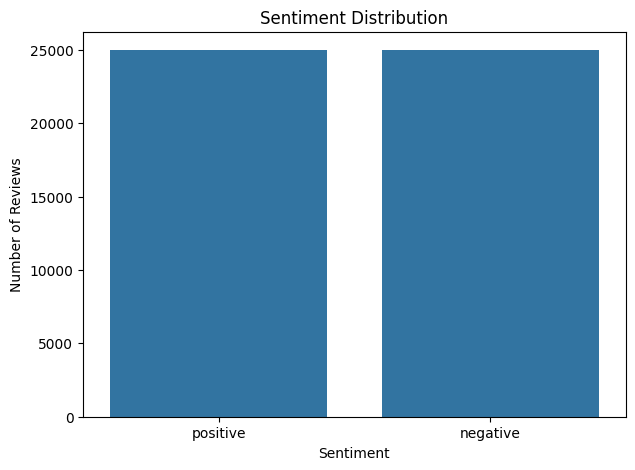

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(x="sentiment", data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

### Observation

The dataset is balanced because it contains almost the same number of positive and negative reviews.

This is important because a balanced dataset helps the model learn both classes fairly.

## 🌟 Example Positive Review

Here I display one positive review from the dataset.

In [22]:
positive_review = df[df["sentiment"] == "positive"]["review"].iloc[0]

print(positive_review)

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

## 💀 Example Negative Review

Here I display one negative review from the dataset.

In [23]:
negative_review = df[df["sentiment"] == "negative"]["review"].iloc[0]

print(negative_review)

Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.


## 📐 Review Length Analysis

Movie reviews can be short or long.  
Review length is important because NLP models often need fixed-length input.

In [24]:
df["review_length"] = df["review"].apply(len)

df["review_length"].describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


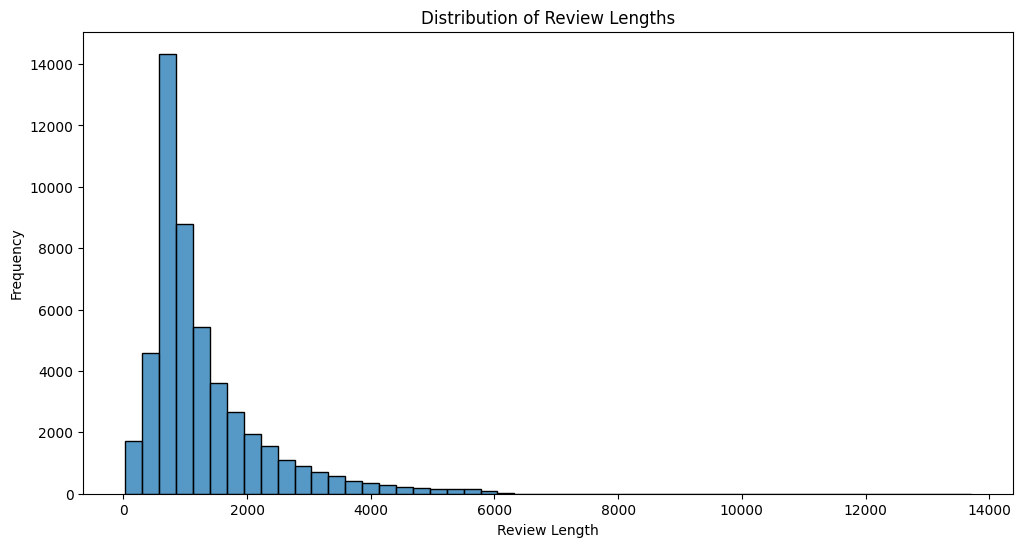

In [25]:
plt.figure(figsize=(12, 6))

sns.histplot(df["review_length"], bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

### Observation

Some reviews are very short, while others are very long.

This means that in future preprocessing steps I may need:

- padding;
- truncation;
- maximum sequence length.

## ⚖️ Average Review Length by Sentiment

Now I compare the average review length for positive and negative reviews.

In [26]:
df.groupby("sentiment")["review_length"].mean()

,review_length
sentiment,
negative,1294.06436
positive,1324.79768


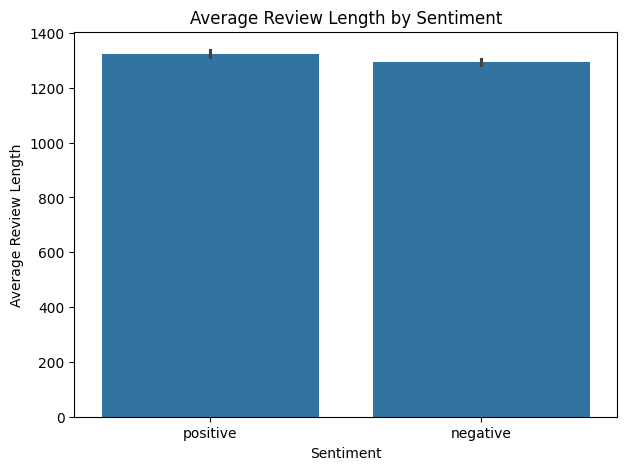

In [27]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x="sentiment",
    y="review_length",
    data=df
)

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Review Length")

plt.show()

## 🧠 Initial NLP Challenges

After exploring the dataset, I noticed several possible challenges:

### 1. Large Vocabulary

The dataset contains many unique words, which can make preprocessing and training more complex.

### 2. Informal Language

Movie reviews often contain slang, emotional words, and informal writing style.

### 3. Long Reviews

Some reviews are very long, so sequence padding and truncation may be needed.

### 4. Emotional Context

People express emotions differently, so the model needs to learn different sentiment patterns.

## 🚀 Plan for Week 2

In Week 2, I plan to focus on preprocessing and baseline modeling.

Planned tasks:

- clean the review text;
- remove HTML tags;
- convert text to lowercase;
- remove punctuation;
- encode sentiment labels;
- apply TF-IDF vectorization;
- train Logistic Regression baseline model;
- evaluate model accuracy.

## 💭 Personal Reflection

This week helped me understand that text data is more complex than simple numerical data.

At first, sentiment analysis seemed easy, but after exploring the dataset, I realized that reviews contain different writing styles, emotions, slang, and long explanations.

I also understood that Exploratory Data Analysis is important because it helps identify possible problems before training the model.

## ✅ Week 1 Conclusion

During Week 1, I explored the IMDB movie review dataset and analyzed its basic structure.

The dataset is:

- clean;
- balanced;
- realistic;
- suitable for NLP;
- useful for sentiment analysis.

This week created a strong foundation for Week 2, where I will clean the text and build the first baseline model.